In [1]:
# Cell 1: Imports and Data Acquisition
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Set plotting style for our report visualizations
sns.set_theme(style="whitegrid")

# Fetch dataset (Bank Marketing is ID 222)
print("Fetching Bank Marketing Dataset from UCI...")
bank_marketing = fetch_ucirepo(id=222)

# Extract features (X) and target (y)
X = bank_marketing.data.features
y = bank_marketing.data.targets

# Combine into a single DataFrame for initial cleaning
df = pd.concat([X, y], axis=1)

# Display basic information
print(f"Dataset Shape: {df.shape}\n")
print("First 5 rows:")
display(df.head())

print("\nData Types and Missing Values:")
df.info()

Fetching Bank Marketing Dataset from UCI...
Dataset Shape: (45211, 17)

First 5 rows:


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no



Data Types and Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          45211 non-null  int64 
 1   job          44923 non-null  object
 2   marital      45211 non-null  object
 3   education    43354 non-null  object
 4   default      45211 non-null  object
 5   balance      45211 non-null  int64 
 6   housing      45211 non-null  object
 7   loan         45211 non-null  object
 8   contact      32191 non-null  object
 9   day_of_week  45211 non-null  int64 
 10  month        45211 non-null  object
 11  duration     45211 non-null  int64 
 12  campaign     45211 non-null  int64 
 13  pdays        45211 non-null  int64 
 14  previous     45211 non-null  int64 
 15  poutcome     8252 non-null   object
 16  y            45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [2]:
# Cell 2: Data Splitting and Preprocessing Pipeline
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Target Encoding: Convert 'yes'/'no' to 1/0
y_binary = y['y'].map({'yes': 1, 'no': 0})

# 2. Train / Validation / Test Split (70 / 15 / 15)
# WE SPLIT FIRST to strictly prevent data leakage
X_temp, X_test, y_temp, y_test = train_test_split(X, y_binary, test_size=0.15, random_state=42, stratify=y_binary)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp) 
# (0.1765 of the remaining 85% yields exactly 15% of the original total)

print(f"Train set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples\n")

# 3. Identify Feature Types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 4. Build Preprocessing Pipelines
# Numeric: Impute missing with median -> Standardize (Required for MLP)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Impute missing with 'unknown' -> One-Hot Encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Fit on Train ONLY, then transform all sets
print("Fitting preprocessing pipeline on training data (Zero Data Leakage)...")
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Extract final feature names for later use in GBDT Feature Importance visualizations
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_cols)

print(f"Preprocessing complete. Features expanded from {X.shape[1]} to {X_train_processed.shape[1]} via One-Hot Encoding.")

Train set: 31646 samples
Validation set: 6783 samples
Test set: 6782 samples

Fitting preprocessing pipeline on training data (Zero Data Leakage)...
Preprocessing complete. Features expanded from 16 to 51 via One-Hot Encoding.


Training Baseline XGBoost Classifier...
Training stopped at iteration: 219


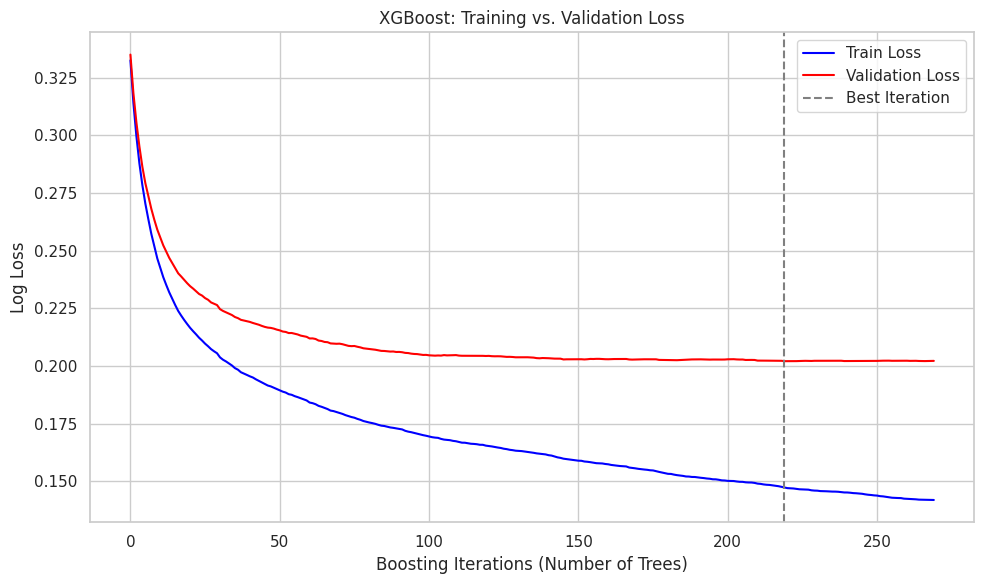

In [3]:
# Cell 3: Gradient Boosted Tree (GBDT) - Baseline & Training Dynamics
import xgboost as xgb
import matplotlib.pyplot as plt

print("Training Baseline XGBoost Classifier...")

# Initialize the model 
# We set a high n_estimators and rely on early stopping to find the optimal point
xgb_base = xgb.XGBClassifier(
    n_estimators=500,        
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=50 # Stop if validation score doesn't improve for 50 rounds
)

# Fit the model using our preprocessed training data
# We pass both train and val sets to eval_set to monitor the learning curve
eval_set = [(X_train_processed, y_train), (X_val_processed, y_val)]

xgb_base.fit(
    X_train_processed, 
    y_train,
    eval_set=eval_set,
    verbose=False
)

print(f"Training stopped at iteration: {xgb_base.best_iteration}")

# --- Visualization 1: Training vs. Validation Loss ---
# This graph is required for the "GBDT Implementation" section of your report
results = xgb_base.evals_result()
epochs = len(results['validation_0']['logloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(10, 6))
plt.plot(x_axis, results['validation_0']['logloss'], label='Train Loss', color='blue')
plt.plot(x_axis, results['validation_1']['logloss'], label='Validation Loss', color='red')
plt.axvline(x=xgb_base.best_iteration, color='grey', linestyle='--', label='Best Iteration')
plt.legend()
plt.ylabel('Log Loss')
plt.xlabel('Boosting Iterations (Number of Trees)')
plt.title('XGBoost: Training vs. Validation Loss')
plt.tight_layout()
plt.show()

In [4]:
# Cell 4: XGBoost Hyperparameter Tuning via Grid Search
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import time

print("Initializing Grid Search... Fire up the CPU threads!")
start_time = time.time()

# Define our hyperparameter grid based on the assignment rubric
param_grid = {
    'learning_rate': [0.01, 0.1, 0.3], # Required: compare at least 3 values
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5]
}

# Initialize a fresh XGBoost classifier
xgb_tuner = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Setup GridSearchCV
# n_jobs=-1 tells scikit-learn to use every available CPU core in parallel
# cv=3 means 3-fold cross-validation to ensure robustness
grid_search = GridSearchCV(
    estimator=xgb_tuner, 
    param_grid=param_grid, 
    scoring='f1', # We optimize for F1-score because term deposit 'yes' answers are imbalanced
    cv=3, 
    n_jobs=-1, 
    verbose=1
)

# Fit the grid search on our training data
grid_search.fit(X_train_processed, y_train)

end_time = time.time()
print(f"\nGrid Search completed in {(end_time - start_time)/60:.2f} minutes.")
print("Best Hyperparameters found:")
for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

# Save the best model for our final GBDT vs MLP comparison later
best_gbdt = grid_search.best_estimator_

Initializing Grid Search... Fire up the CPU threads!
Fitting 3 folds for each of 144 candidates, totalling 432 fits

Grid Search completed in 7.72 minutes.
Best Hyperparameters found:
 - learning_rate: 0.1
 - max_depth: 5
 - n_estimators: 200
 - reg_alpha: 0.1
 - reg_lambda: 1
 - subsample: 0.8


Generating visualizations for the PDF report...



/tmp/ipykernel_433/3907980032.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')


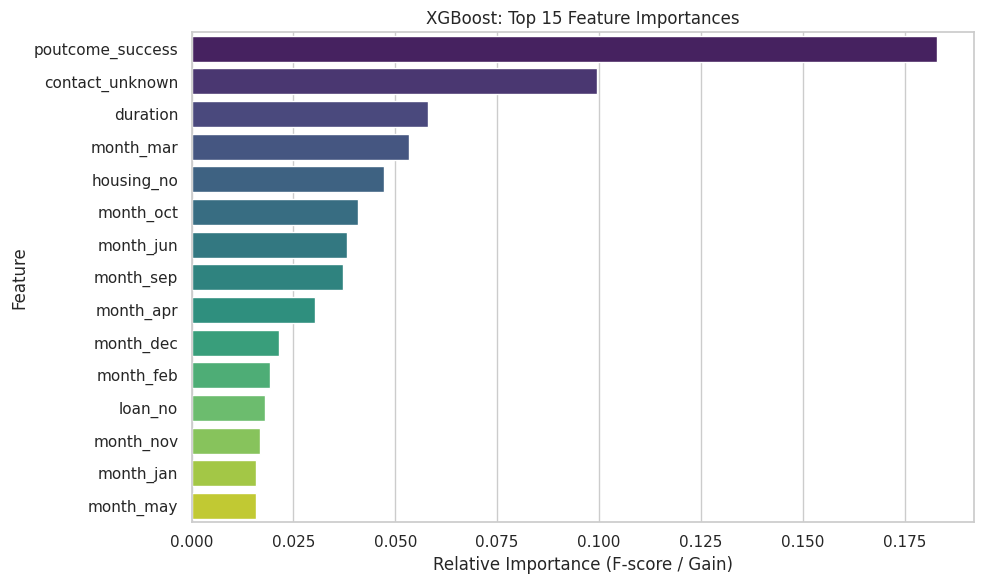

Saved 'gbdt_feature_importance.png' to local directory.

Simulating Learning Rates (0.01, 0.1, 0.3)...


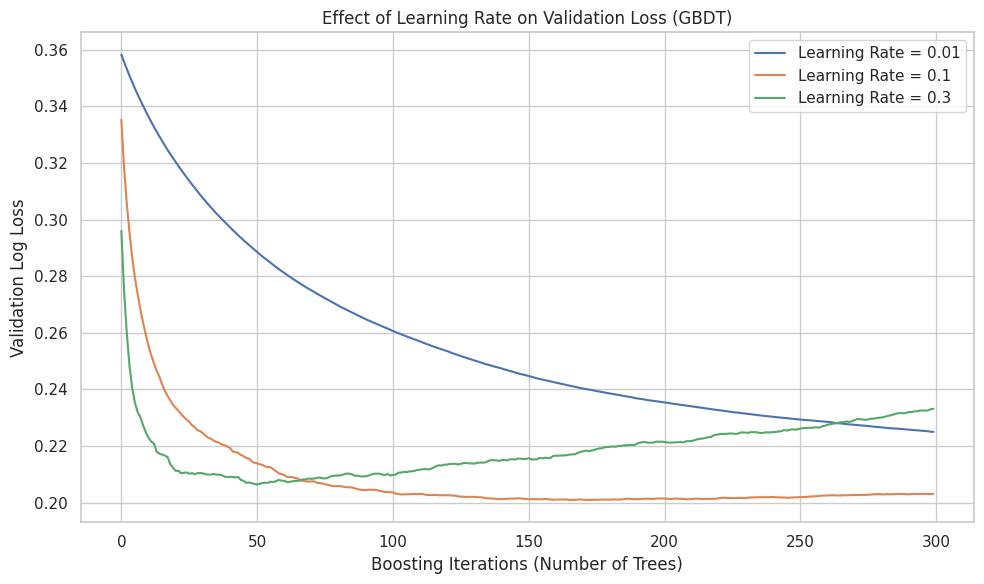

Saved 'gbdt_learning_rate_comparison.png' to local directory.


In [5]:
# Cell 5: GBDT Visualizations for the Report (Updated to auto-save)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

print("Generating visualizations for the PDF report...\n")

# --- Visualization 1: Feature Importance ---
# Extract importances from our grid-searched best model
importances = best_gbdt.feature_importances_

# Combine with the feature names we saved in Cell 2
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 Most Important Features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(15), palette='viridis')
plt.title('XGBoost: Top 15 Feature Importances')
plt.xlabel('Relative Importance (F-score / Gain)')
plt.ylabel('Feature')
plt.tight_layout()

# Save the figure BEFORE showing it
plt.savefig('gbdt_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'gbdt_feature_importance.png' to local directory.\n")

# --- Visualization 2: Effect of Learning Rate ---
print("Simulating Learning Rates (0.01, 0.1, 0.3)...")
learning_rates = [0.01, 0.1, 0.3]
eval_set_lr = [(X_val_processed, y_val)]

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    # Clone our best model's parameters, but strictly override the learning rate
    temp_params = best_gbdt.get_params()
    temp_params['learning_rate'] = lr
    temp_params['n_estimators'] = 300 # Set a fixed number of trees so the x-axis matches
    
    # Initialize and fit
    temp_model = xgb.XGBClassifier(**temp_params)
    temp_model.fit(
        X_train_processed, 
        y_train, 
        eval_set=eval_set_lr, 
        verbose=False
    )
    
    # Extract the validation loss history
    results = temp_model.evals_result()
    val_loss = results['validation_0']['logloss']
    
    # Plot the curve
    plt.plot(range(len(val_loss)), val_loss, label=f'Learning Rate = {lr}')

plt.title('Effect of Learning Rate on Validation Loss (GBDT)')
plt.xlabel('Boosting Iterations (Number of Trees)')
plt.ylabel('Validation Log Loss')
plt.legend()
plt.tight_layout()

# Save the figure BEFORE showing it
plt.savefig('gbdt_learning_rate_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'gbdt_learning_rate_comparison.png' to local directory.")

In [6]:
# Cell 6: Multi-Layer Perceptron (MLP) - Hyperparameter Tuning
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import time

print("Initializing MLP Grid Search... Neural Networks take a bit more time!")
start_time = time.time()

# Define the parameter grid requested by the assignment
mlp_param_grid = {
    'hidden_layer_sizes': [(64,), (128, 64), (256, 128, 64)], # Testing shallow, medium, and deep
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [300] # Cap at 300 epochs to prevent infinite training loops
}

# Initialize the MLP
# We use early_stopping=True so the model internally monitors a fraction of the training data 
# and stops early if the network stops learning, saving massive amounts of time.
mlp_base = MLPClassifier(random_state=42, early_stopping=True)

# Setup GridSearchCV
mlp_grid_search = GridSearchCV(
    estimator=mlp_base,
    param_grid=mlp_param_grid,
    scoring='f1', # Consistent with our GBDT scoring
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit the grid search strictly on our scaled training data
mlp_grid_search.fit(X_train_processed, y_train)

end_time = time.time()
print(f"\nMLP Grid Search completed in {(end_time - start_time)/60:.2f} minutes.")
print("Best MLP Hyperparameters found:")
for param, value in mlp_grid_search.best_params_.items():
    print(f" - {param}: {value}")

# Save the absolute best model for our final comparison
best_mlp = mlp_grid_search.best_estimator_

Initializing MLP Grid Search... Neural Networks take a bit more time!
Fitting 3 folds for each of 18 candidates, totalling 54 fits

MLP Grid Search completed in 0.14 minutes.
Best MLP Hyperparameters found:
 - activation: tanh
 - hidden_layer_sizes: (128, 64)
 - learning_rate_init: 0.01
 - max_iter: 300


Generating MLP visualizations for the PDF report...



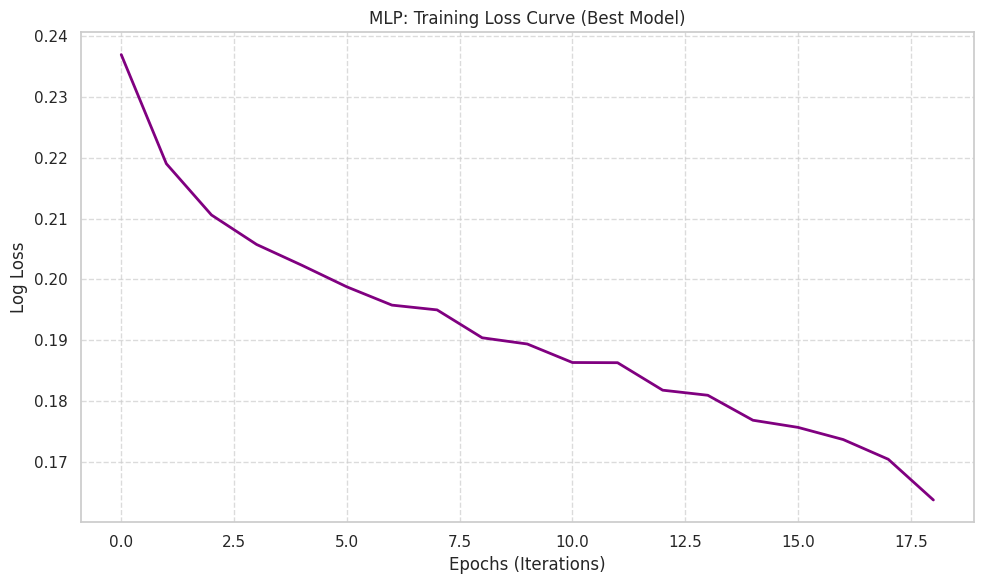

Saved 'mlp_training_loss.png' to local directory.

Extracting architecture performance data from Grid Search...


/tmp/ipykernel_433/3851728276.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Architecture', y='mean_test_score', data=subset, palette='mako')


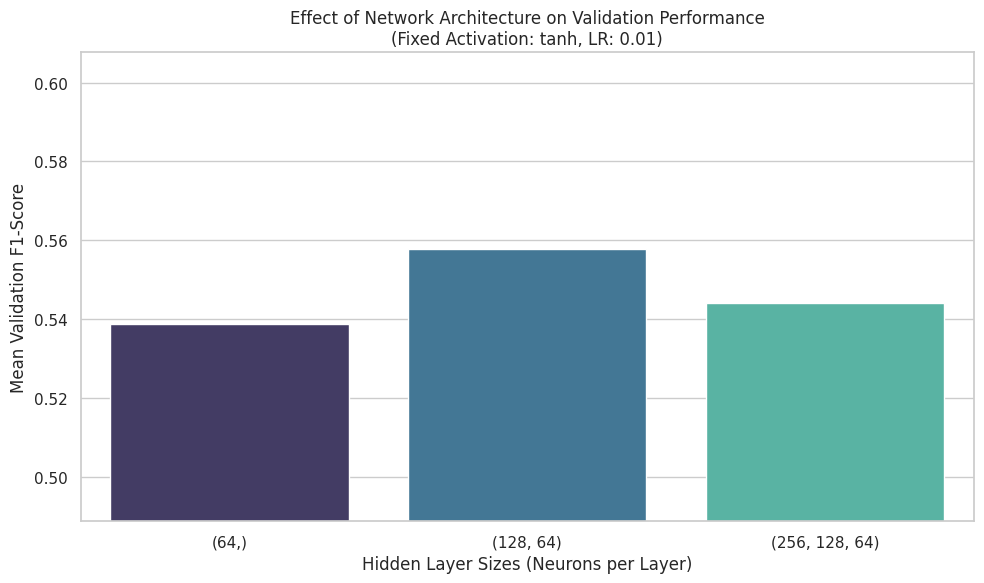

Saved 'mlp_architecture_comparison.png' to local directory.


In [7]:
# Cell 7: MLP Visualizations for the Report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating MLP visualizations for the PDF report...\n")

# --- Visualization 1: Training Loss Curve ---
# Scikit-learn's MLPClassifier conveniently stores the loss history in the loss_curve_ attribute
plt.figure(figsize=(10, 6))
plt.plot(best_mlp.loss_curve_, color='purple', linewidth=2)
plt.title('MLP: Training Loss Curve (Best Model)')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Log Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Save and show
plt.savefig('mlp_training_loss.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'mlp_training_loss.png' to local directory.\n")

# --- Visualization 2: Effect of Network Depth/Width ---
print("Extracting architecture performance data from Grid Search...")
# Convert the massive dictionary of grid search results into a clean DataFrame
cv_results = pd.DataFrame(mlp_grid_search.cv_results_)

# To isolate the effect of architecture, we will filter the dataframe to only look at 
# the rows that used the best activation function and best learning rate.
best_activation = best_mlp.activation
best_lr = best_mlp.learning_rate_init

subset = cv_results[(cv_results['param_activation'] == best_activation) & 
                    (cv_results['param_learning_rate_init'] == best_lr)].copy()

# Convert the tuple objects (e.g., (64,)) into clean strings for the graph's x-axis
subset['Architecture'] = subset['param_hidden_layer_sizes'].astype(str)

plt.figure(figsize=(10, 6))
sns.barplot(x='Architecture', y='mean_test_score', data=subset, palette='mako')
plt.title(f'Effect of Network Architecture on Validation Performance\n(Fixed Activation: {best_activation}, LR: {best_lr})')
plt.xlabel('Hidden Layer Sizes (Neurons per Layer)')
plt.ylabel('Mean Validation F1-Score')

# Dynamically adjust the y-axis to make the differences more visible
min_score = subset['mean_test_score'].min()
max_score = subset['mean_test_score'].max()
plt.ylim(max(0, min_score - 0.05), min(1.0, max_score + 0.05))

plt.tight_layout()

# Save and show
plt.savefig('mlp_architecture_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'mlp_architecture_comparison.png' to local directory.")

Unlocking the Test Set for final evaluation...

Measuring training times on the 9950X3D...

=== Final Model Comparison Table ===


,XGBoost (GBDT),Neural Network (MLP)
Accuracy,0.9087,0.9039
Precision,0.6480,0.6006
Recall,0.4805,0.5309
F1-Score,0.5518,0.5636
AUC-PR,0.6215,0.5896
Training Time (sec),0.5548,1.6343


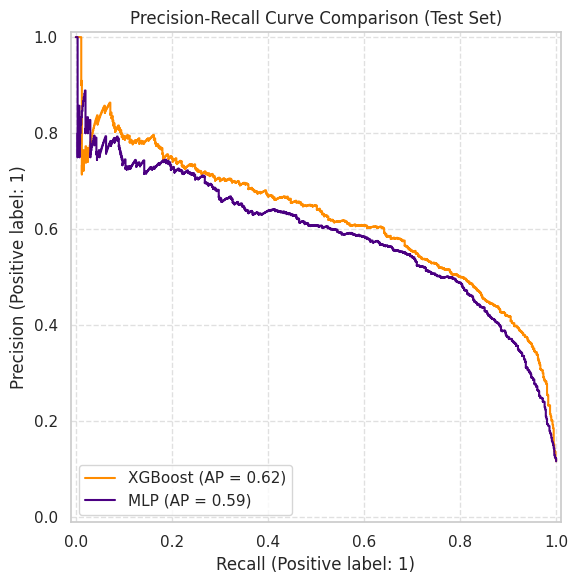

Saved 'model_comparison_pr_curve.png' to local directory.


In [8]:
# Cell 8: GBDT vs MLP - Final Evaluation on Test Set
import time
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, average_precision_score, PrecisionRecallDisplay)

print("Unlocking the Test Set for final evaluation...\n")

# --- 1. Measure Training Time ---
# We will do one fresh fit of our best models to measure pure training time
print("Measuring training times on the 9950X3D...")

start_time = time.time()
best_gbdt.fit(X_train_processed, y_train)
gbdt_time = time.time() - start_time

start_time = time.time()
best_mlp.fit(X_train_processed, y_train)
mlp_time = time.time() - start_time

# --- 2. Generate Predictions on the UNSEEN Test Set ---
# GBDT Predictions
gbdt_preds = best_gbdt.predict(X_test_processed)
gbdt_probs = best_gbdt.predict_proba(X_test_processed)[:, 1]

# MLP Predictions
mlp_preds = best_mlp.predict(X_test_processed)
mlp_probs = best_mlp.predict_proba(X_test_processed)[:, 1]

# --- 3. Calculate Metrics ---
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'AUC-PR': average_precision_score(y_true, y_prob)
    }

gbdt_metrics = get_metrics(y_test, gbdt_preds, gbdt_probs)
mlp_metrics = get_metrics(y_test, mlp_preds, mlp_probs)

# Add training times to the metrics dictionaries
gbdt_metrics['Training Time (sec)'] = gbdt_time
mlp_metrics['Training Time (sec)'] = mlp_time

# --- 4. Create the Summary Comparison Table ---
comparison_df = pd.DataFrame([gbdt_metrics, mlp_metrics], index=['XGBoost (GBDT)', 'Neural Network (MLP)'])
comparison_df = comparison_df.T # Transpose for easier reading in the report

print("\n=== Final Model Comparison Table ===")
display(comparison_df.round(4))

# --- 5. Visualize Precision-Recall Curves ---
fig, ax = plt.subplots(figsize=(8, 6))

PrecisionRecallDisplay.from_predictions(y_test, gbdt_probs, name="XGBoost", ax=ax, color='darkorange')
PrecisionRecallDisplay.from_predictions(y_test, mlp_probs, name="MLP", ax=ax, color='indigo')

plt.title('Precision-Recall Curve Comparison (Test Set)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and show
plt.savefig('model_comparison_pr_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved 'model_comparison_pr_curve.png' to local directory.")